In [1]:
import pandas as pd

In [2]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")

df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df['type'].value_counts()
df['rating'].value_counts().head(10)
df['country'].value_counts().head(10)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [11]:
df= df.copy()
df.drop_duplicates(inplace=True)
df['country']=df['country'].fillna("Unknown")
df['rating']=df['rating'].fillna("Not Rated")
df['director']=df['director'].fillna("Unknown")

df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast            825
country           0
date_added       10
release_year      0
rating            0
duration          3
listed_in         0
description       0
dtype: int64

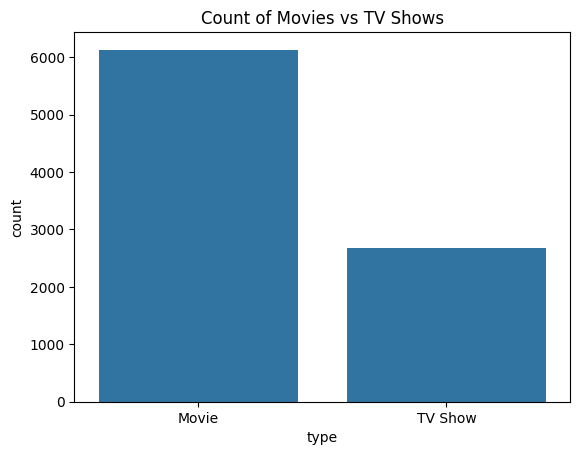

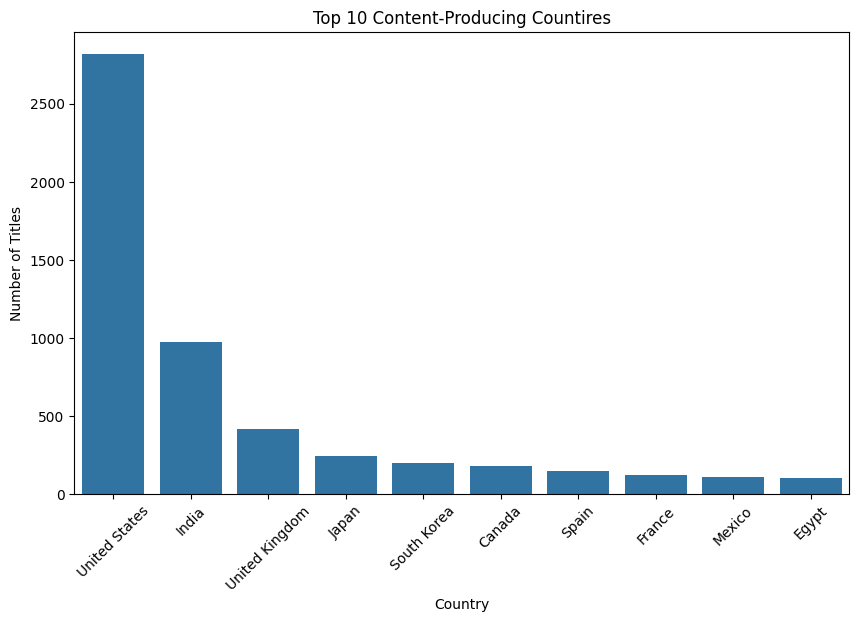

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df,x='type')
plt.title("Count of Movies vs TV Shows")
plt.show()
top_countries =( df[df['country']!="Unknown"]['country'].value_counts().head(10) )


plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.index,y=top_countries.values)
plt.title("Top 10 Content-Producing Countires")
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

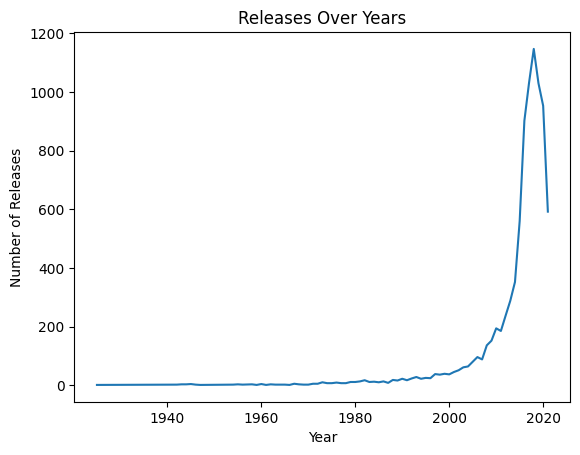

In [14]:
df['release_year']=df['release_year'].astype(int)
df['release_year'].value_counts().sort_index().plot(kind='line',title='Releases Over Years')
plt.xlabel("Year")
plt.ylabel("Number of Releases")
plt.show()